# Model Comparison — Tire Degradation & Anomaly Models

Comprehensive evaluation across degradation model tiers:
- **Linear** — Ridge regression baseline
- **Bayesian** — Hierarchical state-space (NumPyro)
- **GBM** — LightGBM gradient boosting

Plus the **Anomaly** prediction model (LightGBM classifier for outlier/retirement detection).

We compare on: overall accuracy, per-circuit performance, per-compound degradation curves,
weather sensitivity, residual structure, prediction interval calibration, and anomaly detection quality.

In [2]:
import warnings

from f1deg.viz.theme import ACCENT, PALETTE, apply_theme

apply_theme()

warnings.filterwarnings("ignore", category=FutureWarning)

# Model colour assignments (consistent throughout notebook)
MODEL_COLORS = {
    "linear": ACCENT[0],  # rose
    "bayesian": ACCENT[1],  # blue
    "gbm": ACCENT[2],  # green
    "sequence": ACCENT[3],  # peach
}

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", None)

# Load processed data
df = pd.read_parquet("../data/processed/laps_clean.parquet")
data_dir = Path("../data/models")

# Derive year from race_id for temporal analysis
df["year"] = df["race_id"].str[:4].astype(int)

# Classify track temp conditions
df["temp_bin"] = pd.cut(
    df["track_temp"],
    bins=[0, 25, 35, 45, 60],
    labels=["Cold (<25°C)", "Mild (25-35°C)", "Hot (35-45°C)", "Very Hot (>45°C)"],
)

# Flag wet races
df["is_wet"] = df["rainfall"] | df["compound"].isin(["INTERMEDIATE", "WET"])

print(
    f"Data: {len(df):,} laps | {df['race_id'].nunique()} races | {df['circuit_id'].nunique()} circuits"
)
print(f"Years: {sorted(df['year'].unique())} | Drivers: {df['driver_id'].nunique()}")
print(f"Dry laps: {(~df['is_wet']).sum():,} | Wet laps: {df['is_wet'].sum():,}")

Data: 82,094 laps | 92 races | 25 circuits
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)] | Drivers: 31
Dry laps: 81,597 | Wet laps: 497


## 1. Load All Trained Models

In [9]:
from f1deg.models import get_model_class

# NOTE: sequence model excluded — JAX (bayesian) and PyTorch (sequence)
# deadlock when loaded in the same Jupyter process on macOS.
# Sequence model also produces NaN predictions and needs debugging.
load_order = ["linear", "bayesian", "gbm"]

models = {}
for name in load_order:
    path = data_dir / name
    model_file = "model.pkl"
    if (path / model_file).exists():
        try:
            print(f"  Loading {name}...", end=" ", flush=True)
            cls = get_model_class(name)
            models[name] = cls.load(path)
            print("✓")
        except Exception as e:
            print(f"✗ {e}")
    else:
        print(f"  - {name}: not trained yet")

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

# Generate predictions for all models upfront
predictions = {}
for name, model in models.items():
    print(f"  Predicting {name}...", end=" ", flush=True)
    pred = model.predict(df)
    lo, hi = model.predict_interval(df)

    predictions[name] = {
        "pred": pred,
        "lower": lo,
        "upper": hi,
        "residuals": df["lap_time_seconds"].values - pred,
    }
    mae = np.abs(predictions[name]["residuals"]).mean()
    rmse = np.sqrt((predictions[name]["residuals"] ** 2).mean())
    print(f"MAE={mae:.3f}s  RMSE={rmse:.3f}s")

n_models = len(models)

  Loading linear... ✓
  Loading bayesian... ✓
  Loading gbm... ✓

Loaded 3 models: ['linear', 'bayesian', 'gbm']
  Predicting linear... MAE=1.472s  RMSE=2.122s
  Predicting bayesian... MAE=1.260s  RMSE=2.097s
  Predicting gbm... MAE=0.843s  RMSE=1.442s


## 2. Overall Accuracy — Predicted vs Actual

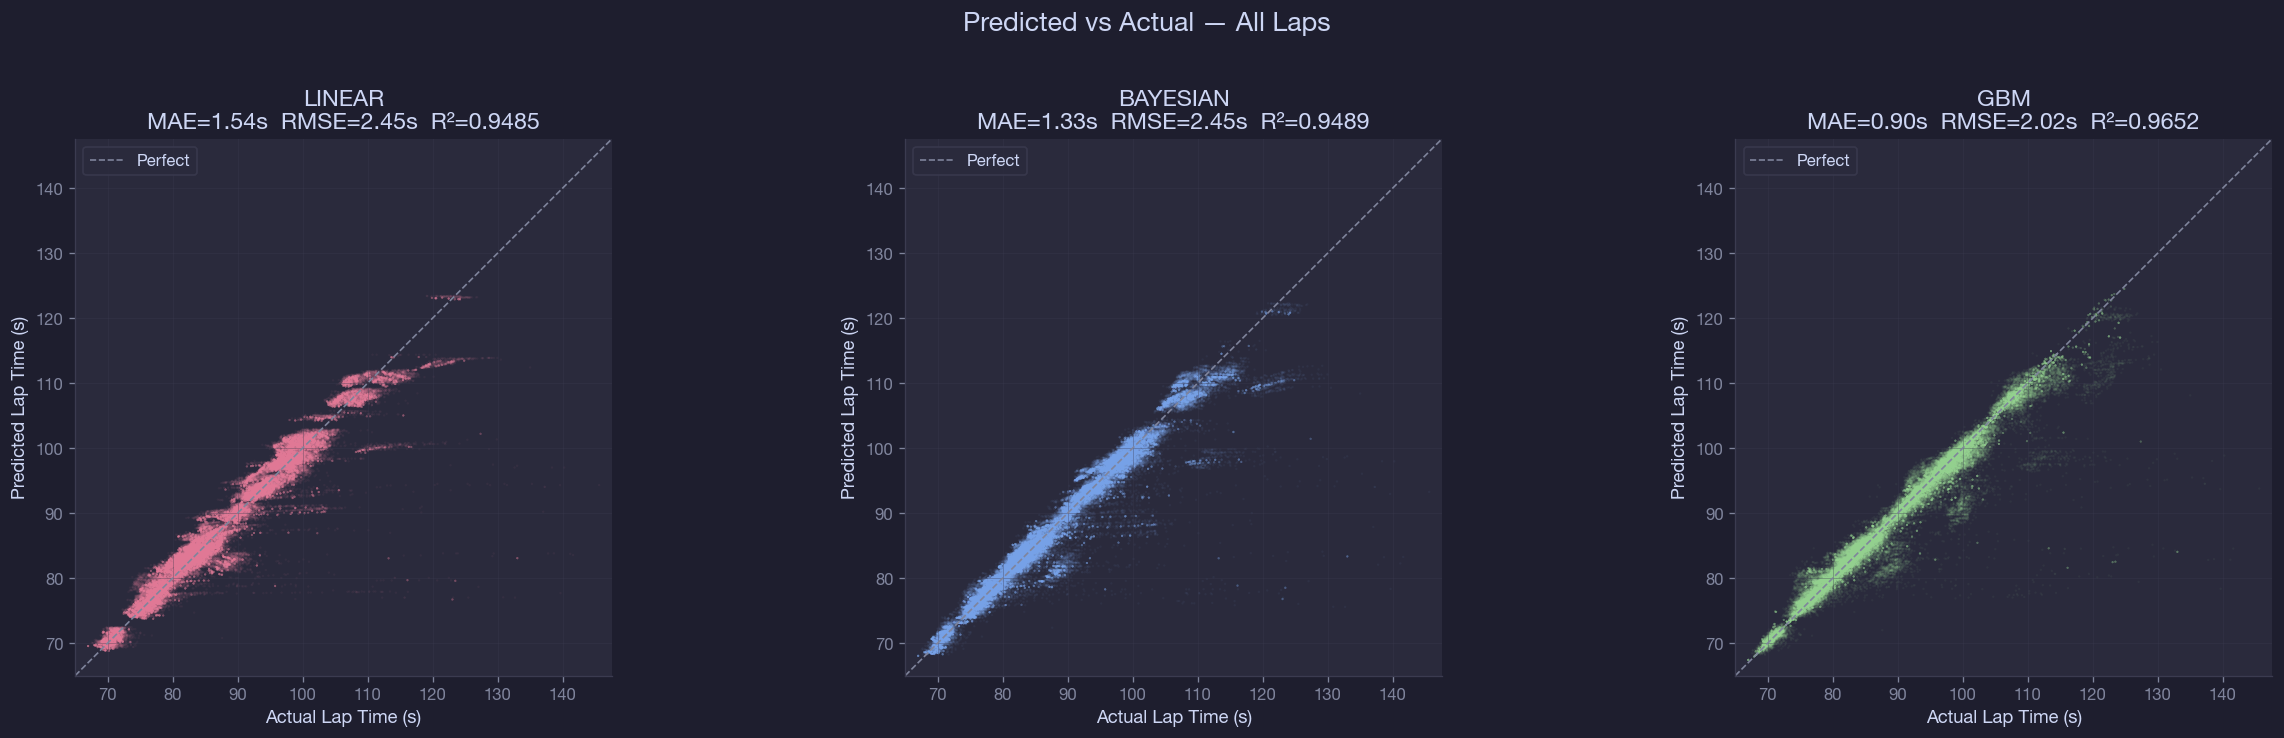

In [4]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)
y_true = df["lap_time_seconds"].values

for ax, (name, preds) in zip(axes[0], predictions.items(), strict=False):
    color = MODEL_COLORS[name]
    ax.scatter(y_true, preds["pred"], alpha=0.05, s=2, c=color, rasterized=True)
    lims = [y_true.min() - 2, y_true.max() + 2]
    ax.plot(lims, lims, "--", color=PALETTE["text_dim"], linewidth=1, label="Perfect")

    mae = np.abs(preds["residuals"]).mean()
    rmse = np.sqrt((preds["residuals"] ** 2).mean())
    r2 = 1 - np.sum(preds["residuals"] ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    ax.set_title(f"{name.upper()}\nMAE={mae:.2f}s  RMSE={rmse:.2f}s  R²={r2:.4f}")
    ax.set_xlabel("Actual Lap Time (s)")
    ax.set_ylabel("Predicted Lap Time (s)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.legend(loc="upper left")

plt.suptitle("Predicted vs Actual — All Laps", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3. Residual Distributions

Are residuals centered at zero? Heavy tails? Systematic bias?

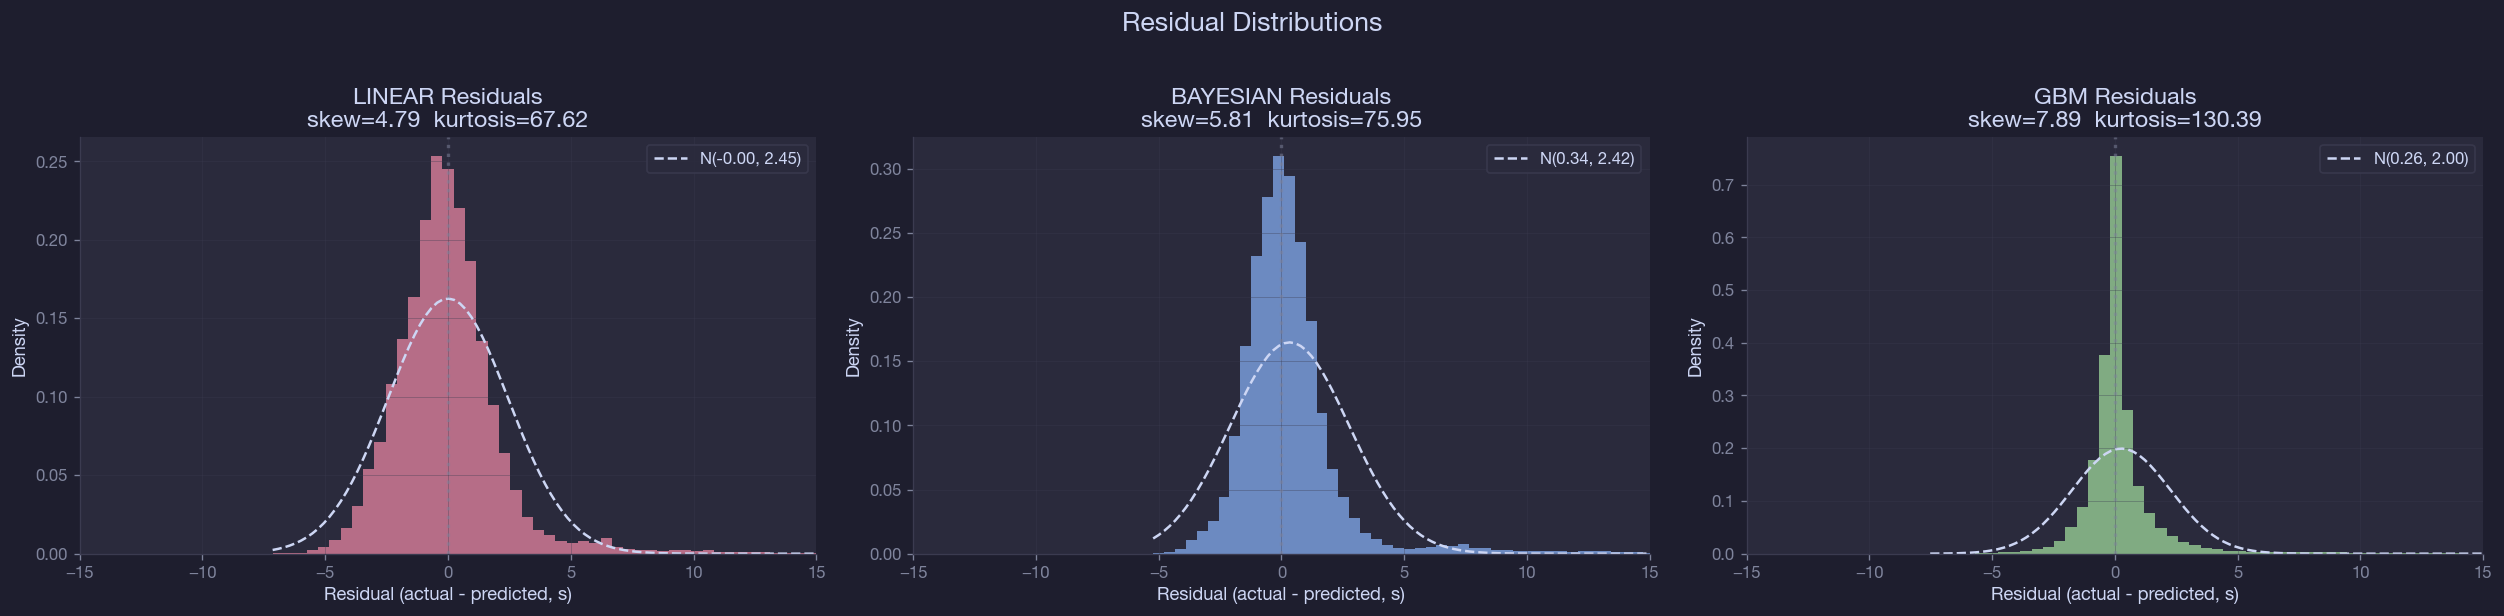

In [5]:
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), squeeze=False)

for ax, (name, preds) in zip(axes[0], predictions.items(), strict=False):
    r = preds["residuals"]
    color = MODEL_COLORS[name]

    ax.hist(r, bins=150, density=True, alpha=0.7, color=color, edgecolor="none")

    # Overlay normal fit
    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(
        x,
        stats.norm.pdf(x, mu, sigma),
        "--",
        color=PALETTE["text"],
        linewidth=1.5,
        label=f"N({mu:.2f}, {sigma:.2f})",
    )

    # Stats annotation
    skew = stats.skew(r)
    kurt = stats.kurtosis(r)
    ax.axvline(0, color=PALETTE["text_dim"], linestyle=":", alpha=0.5)
    ax.set_title(f"{name.upper()} Residuals\nskew={skew:.2f}  kurtosis={kurt:.2f}")
    ax.set_xlabel("Residual (actual - predicted, s)")
    ax.set_ylabel("Density")
    ax.set_xlim(-15, 15)
    ax.legend()

plt.suptitle("Residual Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Per-Circuit MAE Comparison

Which tracks are hardest to predict? Where does each model shine?

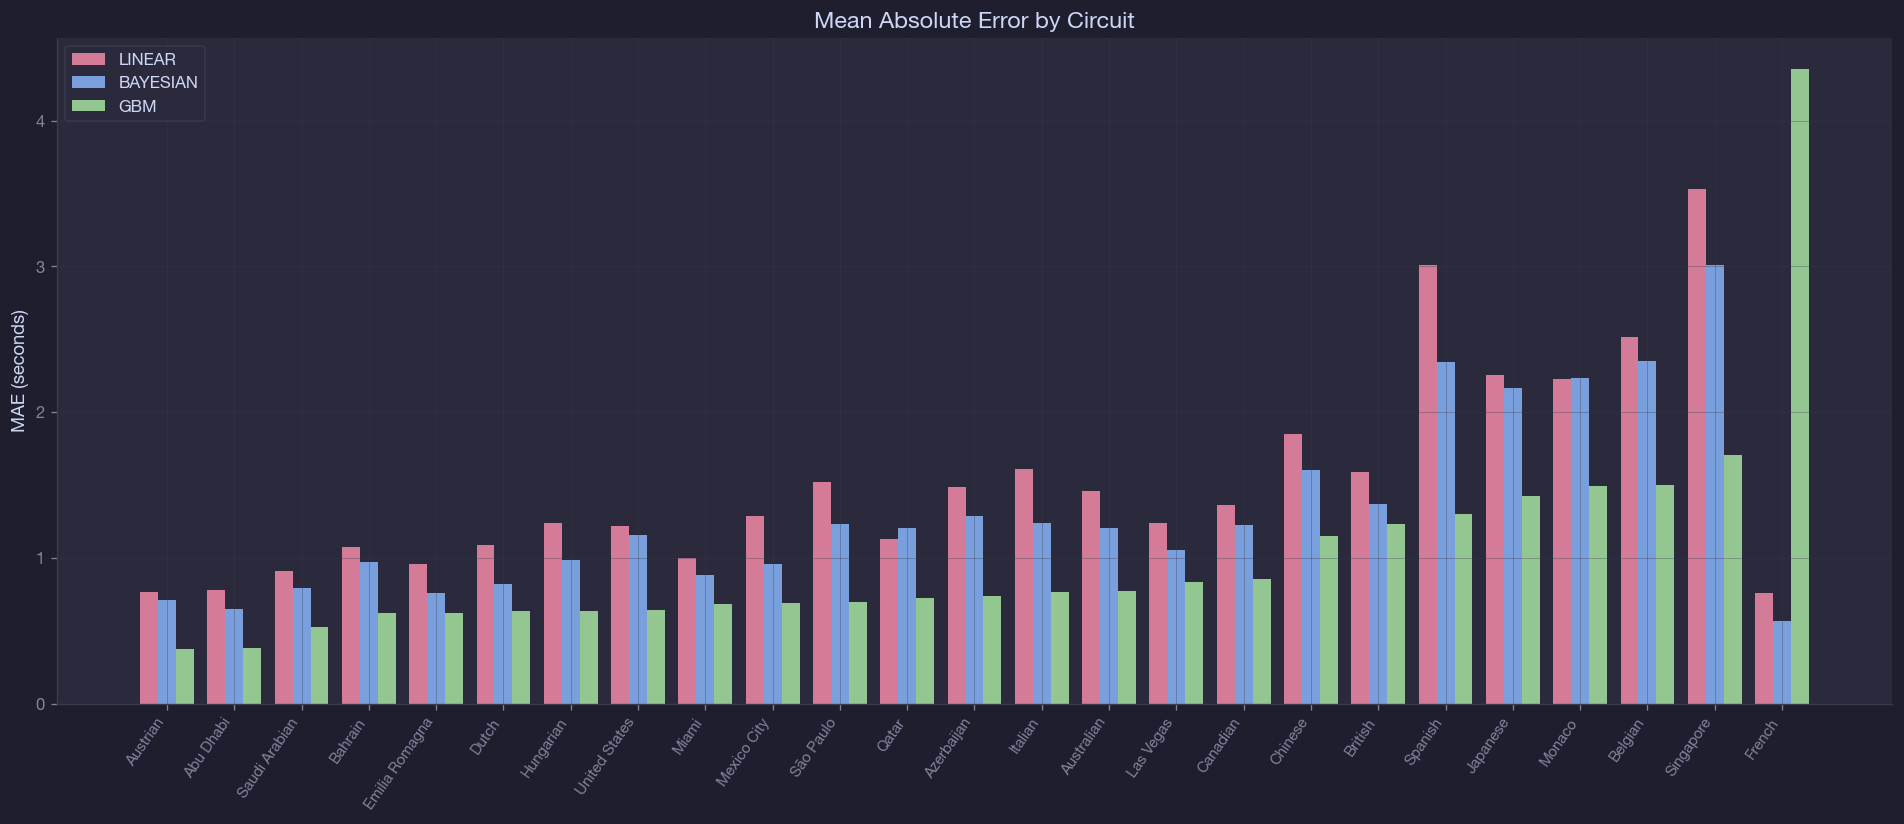


Top 5 hardest circuits per model:

LINEAR:
          circuit_id      mae  n_laps
Singapore Grand Prix 3.533402    7424
  Spanish Grand Prix 3.010346    8741
  Belgian Grand Prix 2.512420    5413
 Japanese Grand Prix 2.255287    5489
   Monaco Grand Prix 2.225787    9069

BAYESIAN:
          circuit_id      mae  n_laps
Singapore Grand Prix 3.005873    7424
  Belgian Grand Prix 2.350965    5413
  Spanish Grand Prix 2.341125    8741
   Monaco Grand Prix 2.230226    9069
 Japanese Grand Prix 2.167371    5489

GBM:
          circuit_id      mae  n_laps
   French Grand Prix 4.351477    1618
Singapore Grand Prix 1.705419    7424
  Belgian Grand Prix 1.497423    5413
   Monaco Grand Prix 1.495794    9069
 Japanese Grand Prix 1.420745    5489


In [6]:
# Compute per-circuit MAE for each model
circuit_metrics = []
for name, preds in predictions.items():
    tmp = df[["circuit_id"]].copy()
    tmp["abs_error"] = np.abs(preds["residuals"])
    per_circuit = tmp.groupby("circuit_id")["abs_error"].agg(["mean", "median", "std", "count"])
    per_circuit.columns = ["mae", "median_ae", "std_ae", "n_laps"]
    per_circuit["model"] = name
    circuit_metrics.append(per_circuit.reset_index())

circuit_df = pd.concat(circuit_metrics)

# Plot: grouped bar chart sorted by GBM MAE (or first available model)
sort_model = "gbm" if "gbm" in predictions else next(iter(predictions.keys()))
circuit_order = (
    circuit_df[circuit_df["model"] == sort_model]
    .sort_values("mae", ascending=True)["circuit_id"]
    .values
)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(circuit_order))
width = 0.8 / n_models

for i, name in enumerate(predictions.keys()):
    subset = circuit_df[circuit_df["model"] == name].set_index("circuit_id").loc[circuit_order]
    bars = ax.bar(
        x + i * width,
        subset["mae"],
        width,
        label=name.upper(),
        color=MODEL_COLORS[name],
        alpha=0.85,
    )

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(
    [c.replace(" Grand Prix", "") for c in circuit_order], rotation=55, ha="right", fontsize=9
)
ax.set_ylabel("MAE (seconds)")
ax.set_title("Mean Absolute Error by Circuit")
ax.legend()
plt.tight_layout()
plt.show()

# Table of worst circuits per model
print("\nTop 5 hardest circuits per model:")
for name in predictions:
    worst = circuit_df[circuit_df["model"] == name].nlargest(5, "mae")[
        ["circuit_id", "mae", "n_laps"]
    ]
    print(f"\n{name.upper()}:")
    print(worst.to_string(index=False))

## 5. Per-Compound Accuracy

Soft tires are underrepresented and degrade faster — do models struggle with them?

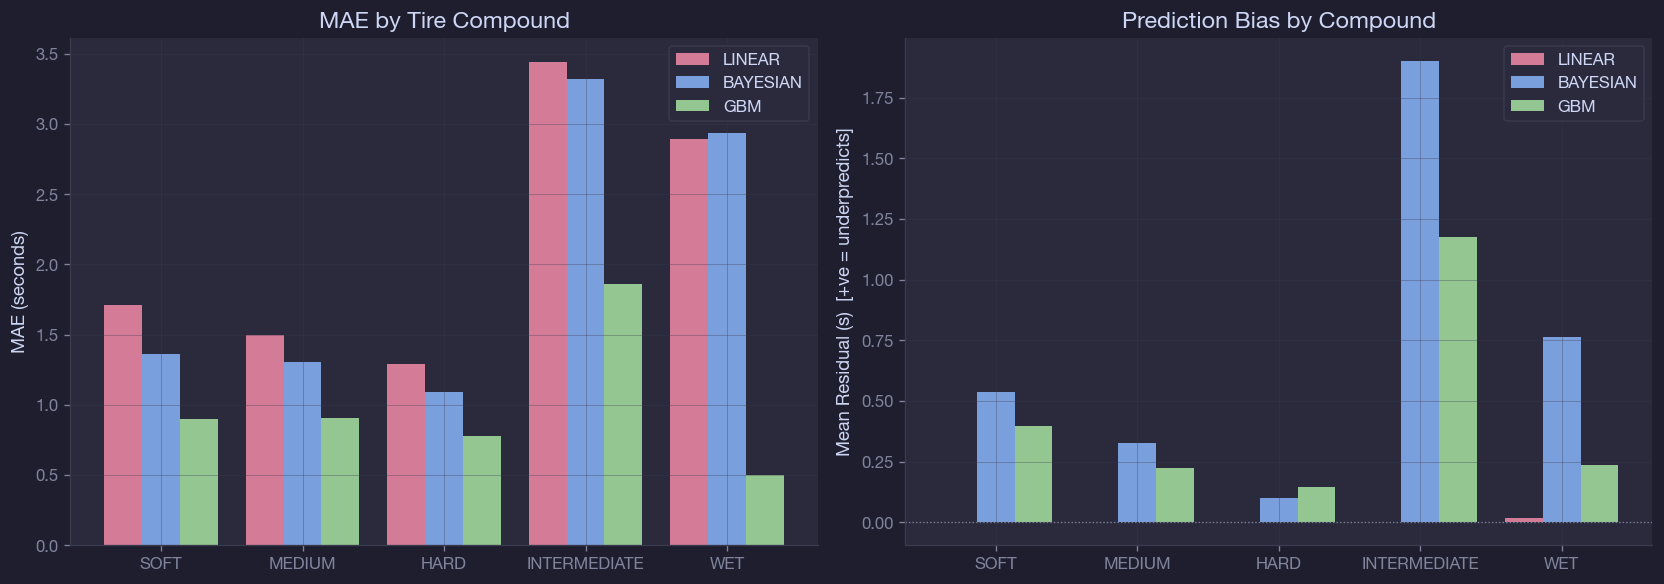

In [7]:
compounds_order = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
compound_metrics = []
for name, preds in predictions.items():
    tmp = df[["compound"]].copy()
    tmp["abs_error"] = np.abs(preds["residuals"])
    tmp["residual"] = preds["residuals"]
    per_comp = tmp.groupby("compound").agg(
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        bias=("residual", "mean"),
        n_laps=("abs_error", "count"),
    )
    per_comp["model"] = name
    compound_metrics.append(per_comp.reset_index())

compound_df = pd.concat(compound_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by compound
ax = axes[0]
x = np.arange(len(compounds_order))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    subset = compound_df[compound_df["model"] == name].set_index("compound")
    vals = [subset.loc[c, "mae"] if c in subset.index else 0 for c in compounds_order]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(compounds_order)
ax.set_ylabel("MAE (seconds)")
ax.set_title("MAE by Tire Compound")
ax.legend()

# Bias (mean residual) by compound — positive = model underpredicts
ax = axes[1]
for i, name in enumerate(predictions.keys()):
    subset = compound_df[compound_df["model"] == name].set_index("compound")
    vals = [subset.loc[c, "bias"] if c in subset.index else 0 for c in compounds_order]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(compounds_order)
ax.axhline(0, color=PALETTE["text_dim"], linestyle=":", linewidth=0.8)
ax.set_ylabel("Mean Residual (s)  [+ve = underpredicts]")
ax.set_title("Prediction Bias by Compound")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Residuals vs Tire Life — Systematic Bias Detection

If residuals trend upward with tire age, the model underestimates degradation (the "cliff").

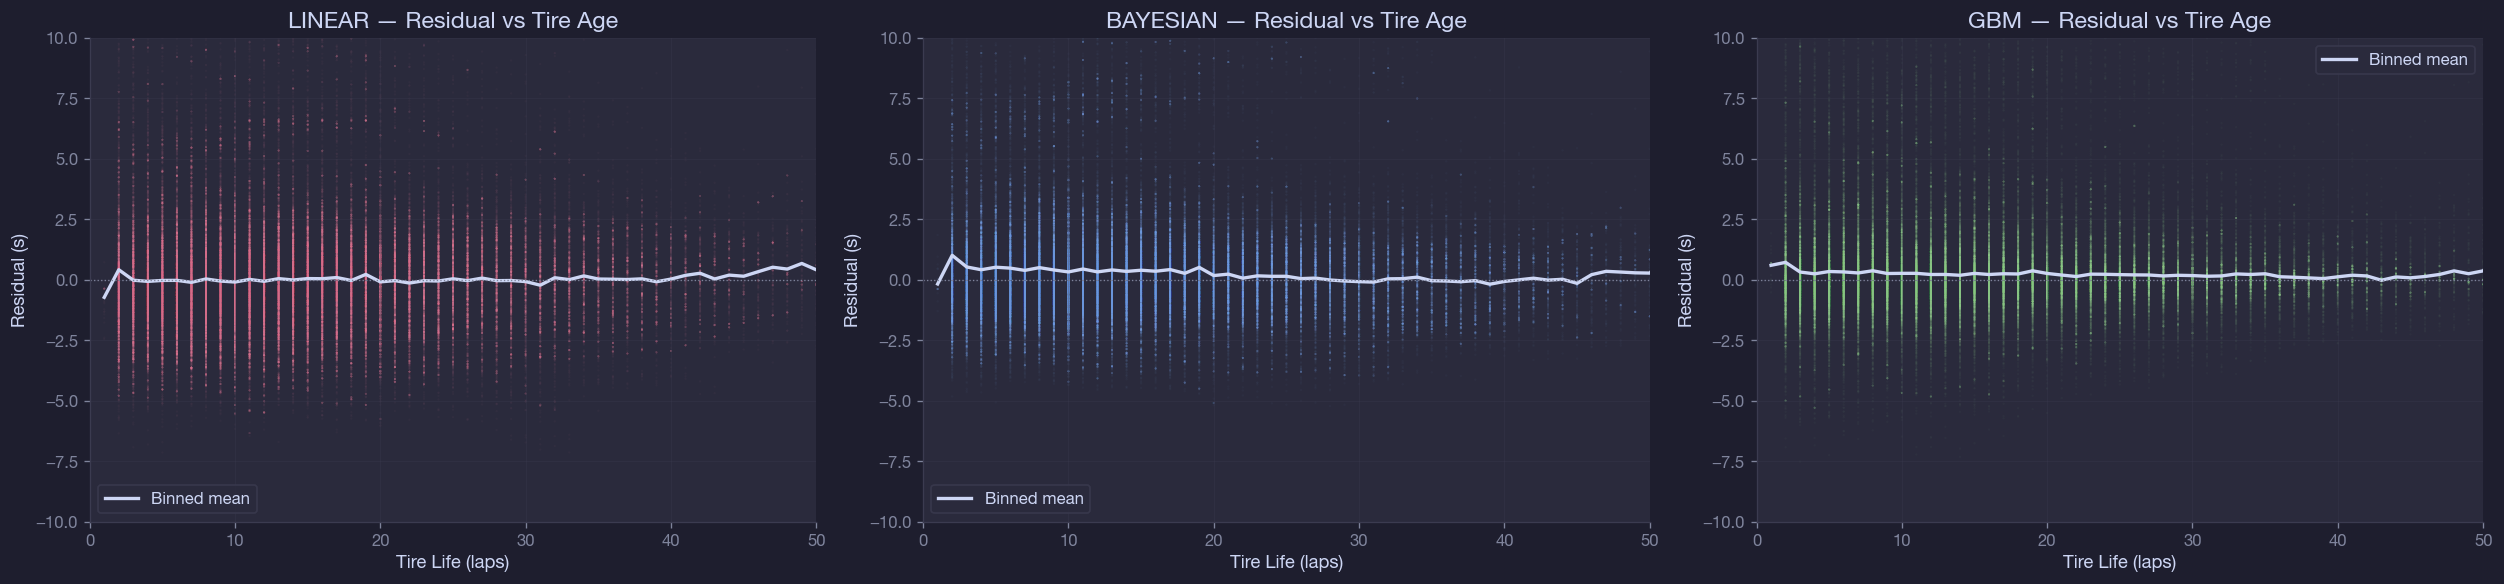

In [8]:
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), squeeze=False)

for ax, (name, preds) in zip(axes[0], predictions.items(), strict=False):
    tl = df["tyre_life"].values
    r = preds["residuals"]
    color = MODEL_COLORS[name]

    ax.scatter(tl, r, alpha=0.03, s=2, c=color, rasterized=True)

    # Binned mean residual trend
    bins = np.arange(1, tl.max() + 1)
    bin_idx = np.clip(np.digitize(tl, bins) - 1, 0, len(bins) - 2)
    bin_means = pd.Series(r).groupby(bin_idx).mean()
    ax.plot(
        bins[: len(bin_means)],
        bin_means.values,
        color=PALETTE["text"],
        linewidth=2,
        label="Binned mean",
    )

    ax.axhline(0, color=PALETTE["text_dim"], linestyle=":", linewidth=0.8)
    ax.set_xlabel("Tire Life (laps)")
    ax.set_ylabel("Residual (s)")
    ax.set_title(f"{name.upper()} — Residual vs Tire Age")
    ax.set_xlim(0, 50)
    ax.set_ylim(-10, 10)
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Prediction Interval Calibration

A well-calibrated 95% PI should contain ~95% of actual values. We also check the PI width — 
narrower is better (more informative), as long as coverage is maintained.

Model          95% Coverage   Mean PI Width    Median PI
linear               96.6% ✓           9.62s        9.62s
bayesian              5.6% ⚠           0.18s        0.18s
gbm                  95.3% ✓           7.96s        6.85s



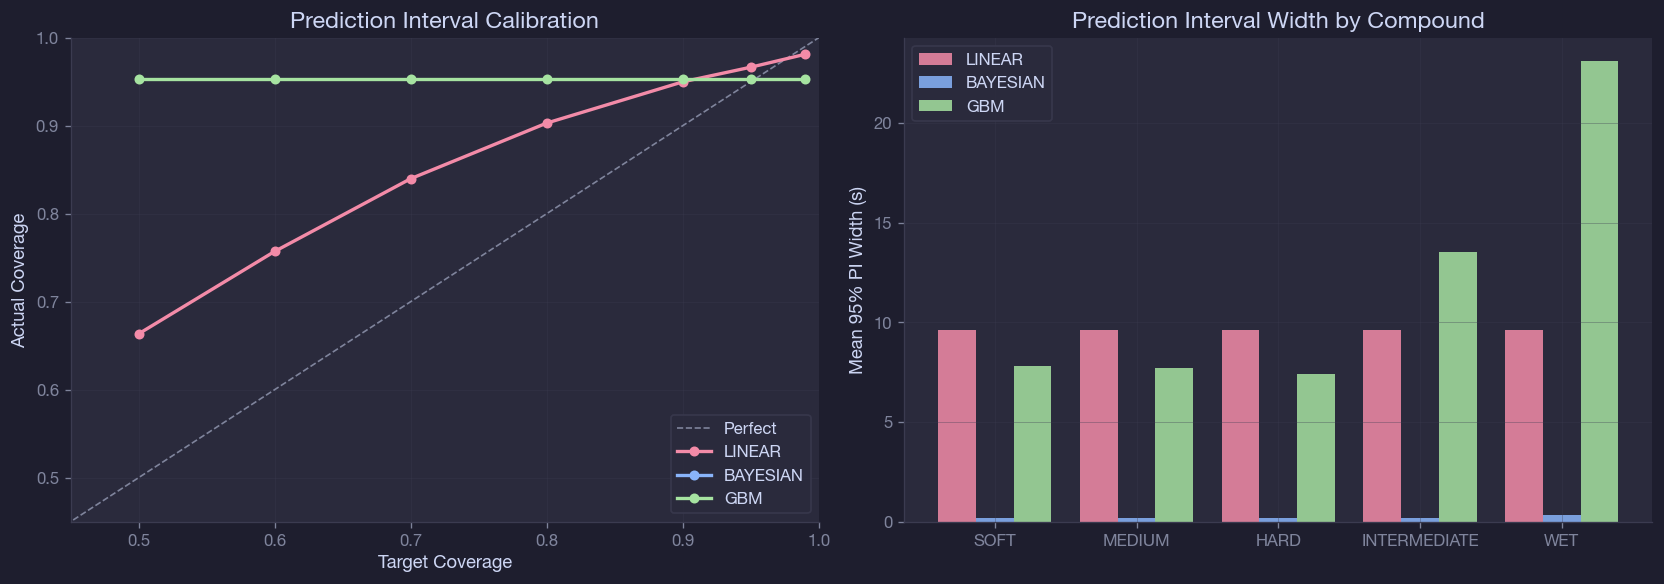

In [9]:
y_true = df["lap_time_seconds"].values

# Overall calibration
print("=" * 65)
print(f"{'Model':<12} {'95% Coverage':>14} {'Mean PI Width':>15} {'Median PI':>12}")
print("=" * 65)
for name, preds in predictions.items():
    in_interval = (y_true >= preds["lower"]) & (y_true <= preds["upper"])
    coverage = in_interval.mean()
    width = (preds["upper"] - preds["lower"]).mean()
    med_width = np.median(preds["upper"] - preds["lower"])
    flag = " ✓" if abs(coverage - 0.95) < 0.05 else " ⚠"
    print(f"{name:<12} {coverage:>13.1%}{flag} {width:>14.2f}s {med_width:>11.2f}s")
print()

# Calibration plot: check multiple quantile levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage at multiple alpha levels
alphas = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color=PALETTE["text_dim"], linewidth=1, label="Perfect")

for name, model in models.items():
    coverages = []
    for target in alphas:
        alpha = 1 - target
        lo, hi = model.predict_interval(df, alpha=alpha)
        cov = ((y_true >= lo) & (y_true <= hi)).mean()
        coverages.append(cov)
    ax.plot(alphas, coverages, "o-", color=MODEL_COLORS[name], label=name.upper(), linewidth=2)

ax.set_xlabel("Target Coverage")
ax.set_ylabel("Actual Coverage")
ax.set_title("Prediction Interval Calibration")
ax.legend()
ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.45, 1.0)

# Right: PI width by compound
ax = axes[1]
width_data = []
for name, preds in predictions.items():
    for compound in compounds_order:
        mask = df["compound"] == compound
        if mask.sum() > 0:
            w = (preds["upper"][mask] - preds["lower"][mask]).mean()
            width_data.append({"model": name, "compound": compound, "pi_width": w})

width_df = pd.DataFrame(width_data)
x = np.arange(len(compounds_order))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    subset = width_df[width_df["model"] == name].set_index("compound")
    vals = [subset.loc[c, "pi_width"] if c in subset.index else 0 for c in compounds_order]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(compounds_order)
ax.set_ylabel("Mean 95% PI Width (s)")
ax.set_title("Prediction Interval Width by Compound")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Weather Sensitivity — Dry vs Wet Performance

Models may fail in wet conditions due to limited training data (only ~5% of laps are wet).

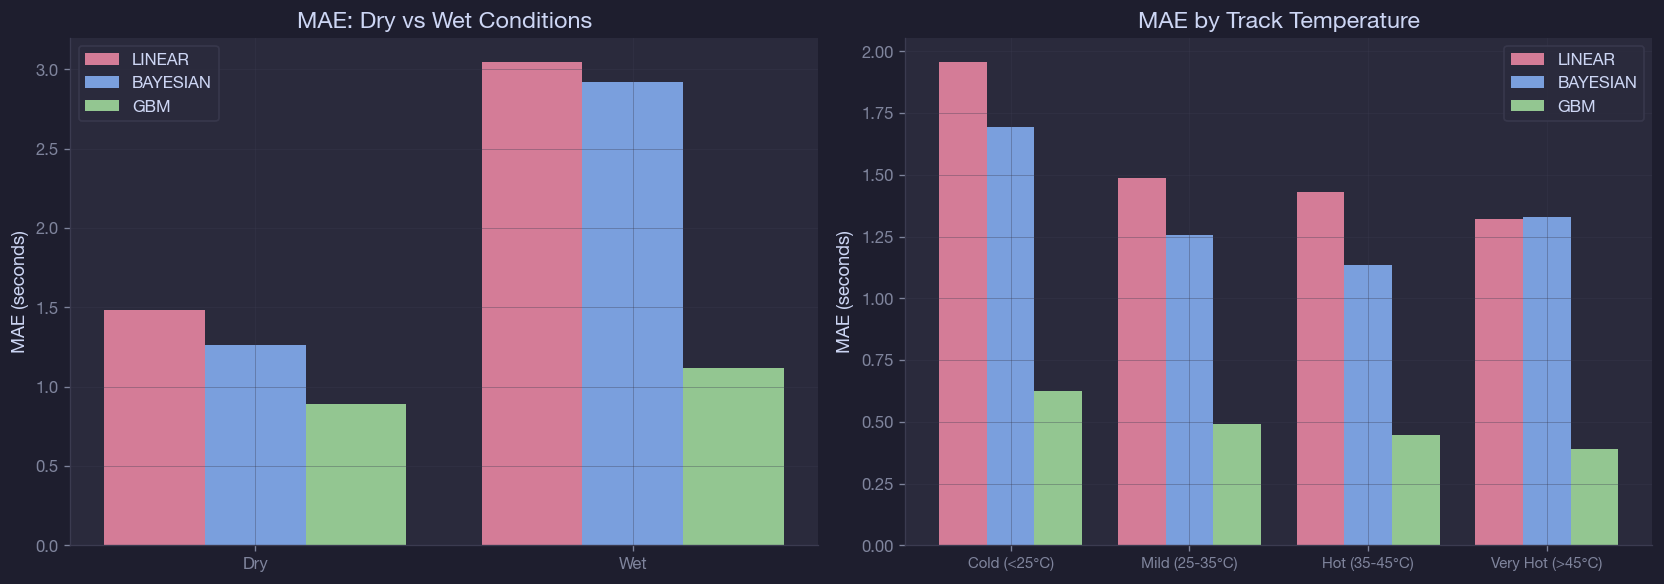

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MAE by condition (dry / wet) and track temp bin
condition_data = []
for name, preds in predictions.items():
    for cond_name, mask in [("Dry", ~df["is_wet"]), ("Wet", df["is_wet"])]:
        if mask.sum() > 0:
            mae = np.abs(preds["residuals"][mask]).mean()
            condition_data.append(
                {"model": name, "condition": cond_name, "mae": mae, "n": mask.sum()}
            )

cond_df = pd.DataFrame(condition_data)
ax = axes[0]
conditions = ["Dry", "Wet"]
x = np.arange(len(conditions))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    subset = cond_df[cond_df["model"] == name].set_index("condition")
    vals = [subset.loc[c, "mae"] if c in subset.index else 0 for c in conditions]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(conditions)
ax.set_ylabel("MAE (seconds)")
ax.set_title("MAE: Dry vs Wet Conditions")
ax.legend()

# Right: MAE by track temperature bin
ax = axes[1]
temp_data = []
temp_labels = ["Cold (<25°C)", "Mild (25-35°C)", "Hot (35-45°C)", "Very Hot (>45°C)"]
for name, preds in predictions.items():
    for tbin in temp_labels:
        mask = df["temp_bin"] == tbin
        if mask.sum() > 50:
            mae = np.abs(preds["residuals"][mask]).mean()
            temp_data.append({"model": name, "temp_bin": tbin, "mae": mae, "n": mask.sum()})

temp_df = pd.DataFrame(temp_data)
available_temps = [t for t in temp_labels if t in temp_df["temp_bin"].values]
x = np.arange(len(available_temps))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    subset = temp_df[temp_df["model"] == name].set_index("temp_bin")
    vals = [subset.loc[c, "mae"] if c in subset.index else 0 for c in available_temps]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(available_temps, fontsize=9)
ax.set_ylabel("MAE (seconds)")
ax.set_title("MAE by Track Temperature")
ax.legend()

plt.tight_layout()
plt.show()

## 10. Year-over-Year Stability

Do models generalize across regulation eras? 2022 introduced ground-effect cars; tire behaviour
may have shifted across seasons.

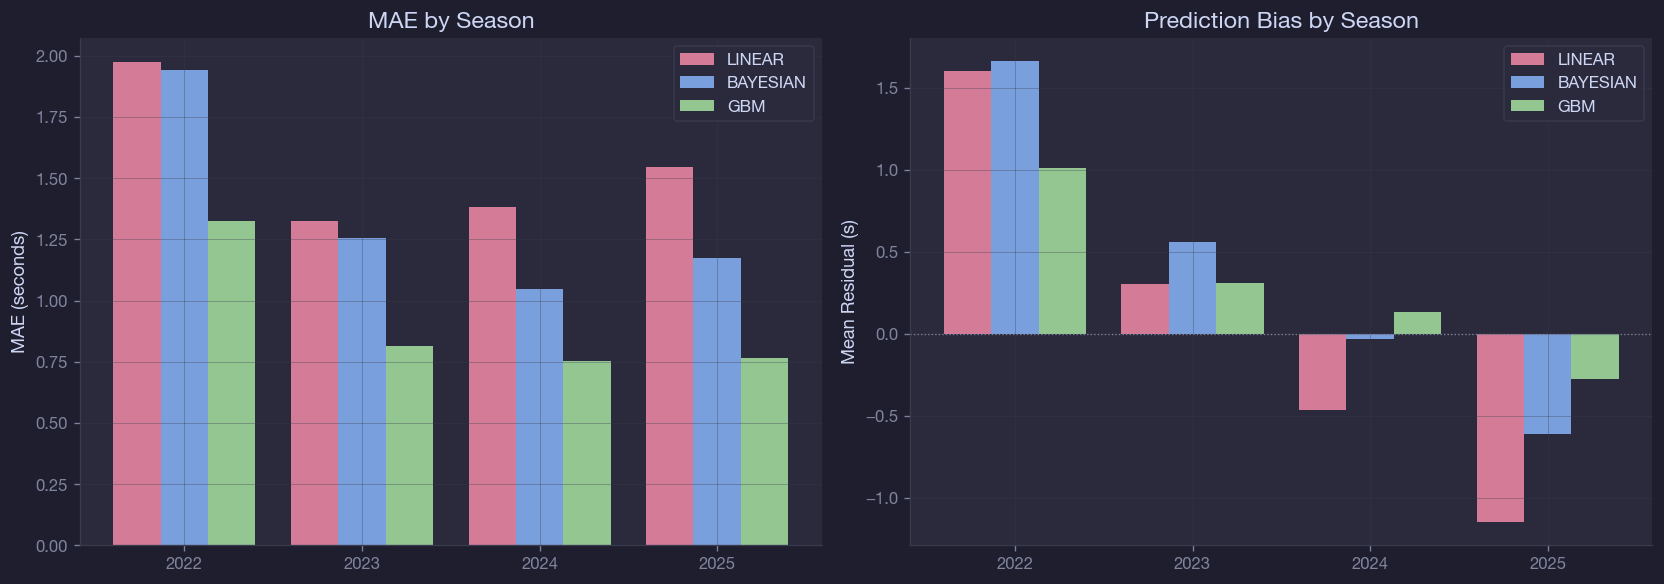

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years = sorted(df["year"].unique())

# Left: MAE by year
ax = axes[0]
x = np.arange(len(years))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    maes = []
    for yr in years:
        mask = df["year"] == yr
        maes.append(np.abs(predictions[name]["residuals"][mask]).mean())
    ax.bar(x + i * width, maes, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(years)
ax.set_ylabel("MAE (seconds)")
ax.set_title("MAE by Season")
ax.legend()

# Right: bias (mean residual) by year — does the model drift?
ax = axes[1]
for i, name in enumerate(predictions.keys()):
    biases = []
    for yr in years:
        mask = df["year"] == yr
        biases.append(predictions[name]["residuals"][mask].mean())
    ax.bar(x + i * width, biases, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(years)
ax.axhline(0, color=PALETTE["text_dim"], linestyle=":", linewidth=0.8)
ax.set_ylabel("Mean Residual (s)")
ax.set_title("Prediction Bias by Season")
ax.legend()

plt.tight_layout()
plt.show()

## 11. Stint-Level Analysis — Late-Stint Accuracy

Strategy decisions hinge on late-stint pace. How accurate are models at high tire age (>20 laps)?

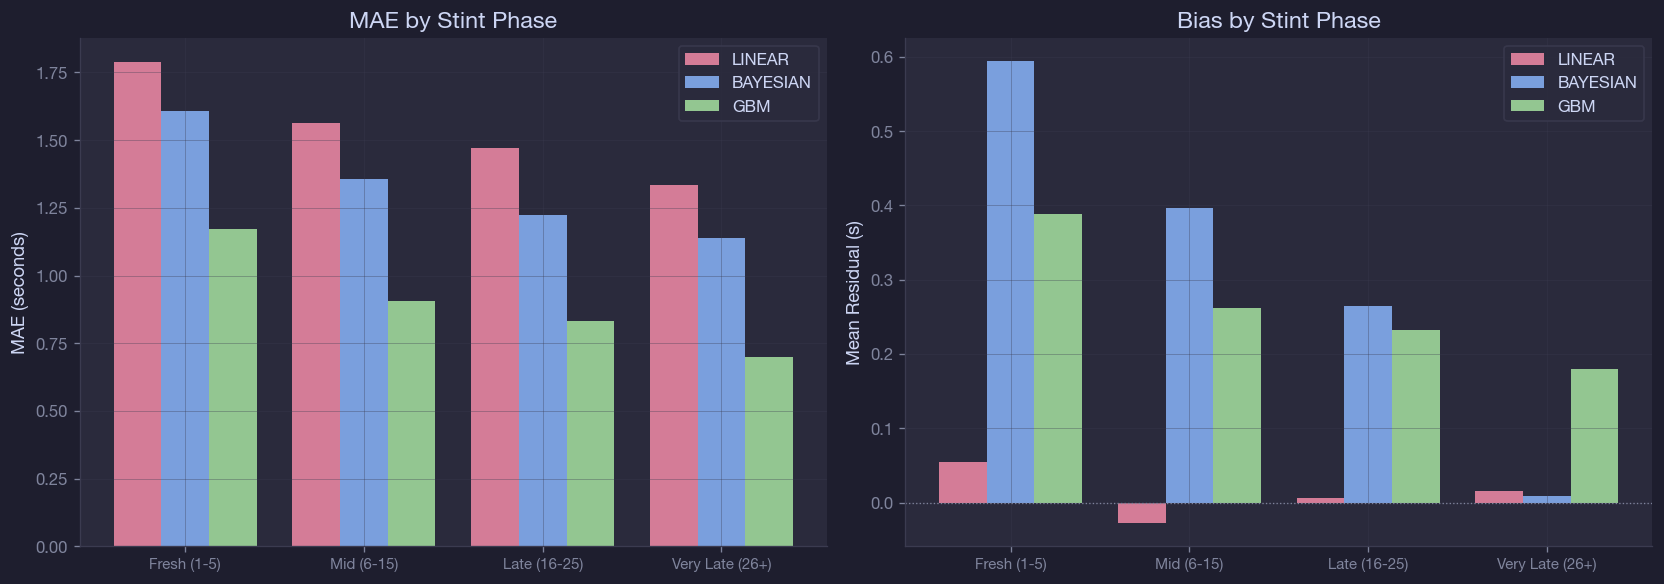


Stint phase metrics:
                    bias                    mae              
model           bayesian    gbm linear bayesian    gbm linear
stint_phase                                                  
Fresh (1-5)        0.595  0.389  0.055    1.606  1.172  1.789
Late (16-25)       0.265  0.232  0.006    1.222  0.832  1.471
Mid (6-15)         0.397  0.262 -0.028    1.358  0.905  1.565
Very Late (26+)    0.009  0.180  0.016    1.137  0.698  1.333


In [12]:
stint_bins = [
    (1, 5, "Fresh (1-5)"),
    (6, 15, "Mid (6-15)"),
    (16, 25, "Late (16-25)"),
    (26, 99, "Very Late (26+)"),
]

stint_data = []
for name, preds in predictions.items():
    for lo, hi, label in stint_bins:
        mask = (df["tyre_life"] >= lo) & (df["tyre_life"] <= hi)
        if mask.sum() > 100:
            mae = np.abs(preds["residuals"][mask]).mean()
            bias = preds["residuals"][mask].mean()
            stint_data.append(
                {"model": name, "stint_phase": label, "mae": mae, "bias": bias, "n": mask.sum()}
            )

stint_df = pd.DataFrame(stint_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [s[2] for s in stint_bins]

ax = axes[0]
x = np.arange(len(labels))
width = 0.8 / n_models
for i, name in enumerate(predictions.keys()):
    subset = stint_df[stint_df["model"] == name].set_index("stint_phase")
    vals = [subset.loc[label, "mae"] if label in subset.index else 0 for label in labels]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("MAE (seconds)")
ax.set_title("MAE by Stint Phase")
ax.legend()

ax = axes[1]
for i, name in enumerate(predictions.keys()):
    subset = stint_df[stint_df["model"] == name].set_index("stint_phase")
    vals = [subset.loc[label, "bias"] if label in subset.index else 0 for label in labels]
    ax.bar(x + i * width, vals, width, label=name.upper(), color=MODEL_COLORS[name], alpha=0.85)
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color=PALETTE["text_dim"], linestyle=":", linewidth=0.8)
ax.set_ylabel("Mean Residual (s)")
ax.set_title("Bias by Stint Phase")
ax.legend()

plt.tight_layout()
plt.show()

# Print the numbers
print("\nStint phase metrics:")
print(
    stint_df.pivot_table(
        index="stint_phase", columns="model", values=["mae", "bias"], aggfunc="first"
    )
    .round(3)
    .to_string()
)

## 12. Error Heatmap — Circuit × Compound

Which circuit-compound combinations are hardest? This identifies where to focus model improvements.

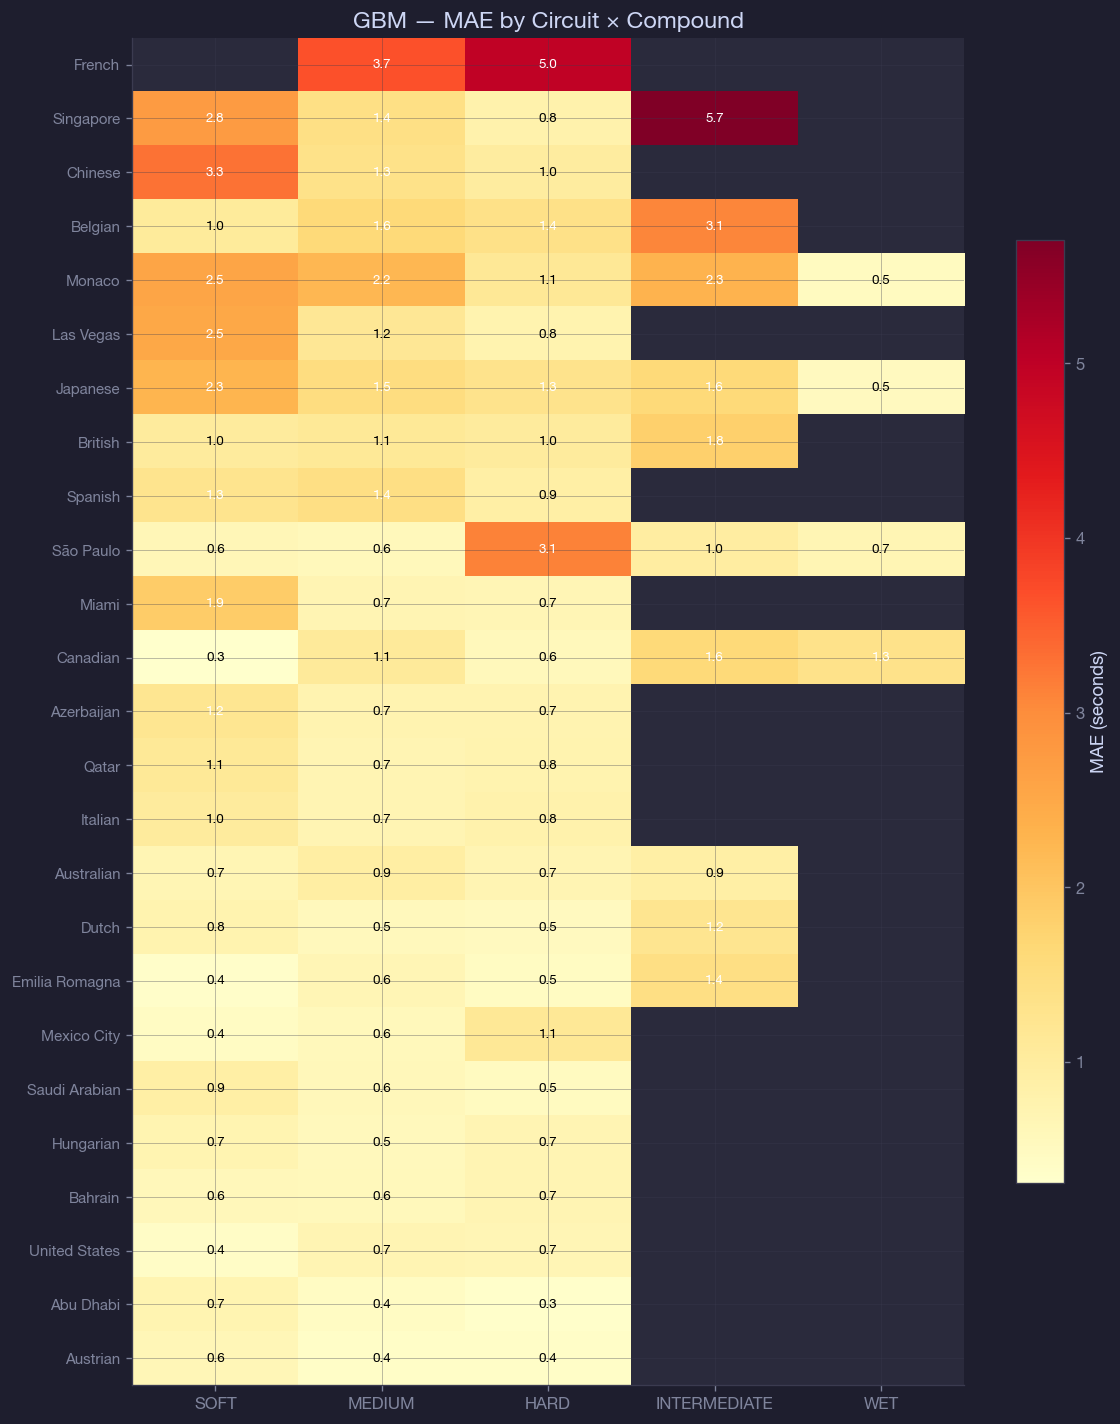

In [13]:
# Use best model (GBM if available)
best_model = "gbm" if "gbm" in predictions else next(iter(predictions.keys()))
preds = predictions[best_model]

tmp = df[["circuit_id", "compound"]].copy()
tmp["abs_error"] = np.abs(preds["residuals"])
pivot = tmp.pivot_table(index="circuit_id", columns="compound", values="abs_error", aggfunc="mean")

# Sort circuits by overall MAE
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
# Reorder compounds
col_order = [c for c in ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"] if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_order)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([c.replace(" Grand Prix", "") for c in pivot.index], fontsize=9)

# Annotate cells with values
for i in range(len(pivot.index)):
    for j in range(len(col_order)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            color = "white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, label="MAE (seconds)", shrink=0.7)
ax.set_title(f"{best_model.upper()} — MAE by Circuit x Compound")
plt.tight_layout()
plt.show()

## 13. Summary Table

All key metrics in one place for quick comparison.

In [14]:
y_true = df["lap_time_seconds"].values
summary_rows = []

for name, preds in predictions.items():
    r = preds["residuals"]
    in_pi = (y_true >= preds["lower"]) & (y_true <= preds["upper"])

    # Late stint (>20 laps)
    late_mask = df["tyre_life"] > 20
    wet_mask = df["is_wet"]

    row = {
        "Model": name.upper(),
        "MAE (s)": f"{np.abs(r).mean():.3f}",
        "RMSE (s)": f"{np.sqrt((r**2).mean()):.3f}",
        "R²": f"{1 - (r**2).sum() / ((y_true - y_true.mean()) ** 2).sum():.4f}",
        "Bias (s)": f"{r.mean():+.3f}",
        "95% PI Coverage": f"{in_pi.mean():.1%}",
        "PI Width (s)": f"{(preds['upper'] - preds['lower']).mean():.2f}",
        "Late Stint MAE": f"{np.abs(r[late_mask]).mean():.3f}",
        "Wet MAE": f"{np.abs(r[wet_mask]).mean():.3f}" if wet_mask.sum() > 0 else "N/A",
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("Model")
print(summary.to_string())
print(
    f"\n(Based on {len(df):,} laps across {df['race_id'].nunique()} races, {df['circuit_id'].nunique()} circuits)"
)

         MAE (s) RMSE (s)      R² Bias (s) 95% PI Coverage PI Width (s) Late Stint MAE Wet MAE
Model                                                                                         
LINEAR     1.541    2.454  0.9485   -0.000           96.6%         9.62          1.374   3.048
BAYESIAN   1.329    2.445  0.9489   +0.336            5.6%         0.18          1.143   2.919
GBM        0.897    2.019  0.9652   +0.261           95.3%         7.96          0.735   1.118

(Based on 165,614 laps across 92 races, 25 circuits)


## 14. Anomaly Model — Load & Evaluate

The anomaly model predicts the probability that a lap is anomalous (outlier, safety car, retirement-adjacent).
This is a classification task evaluated on the **full** dataset (including outliers).

In [4]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from f1deg.models.anomaly import AnomalyPredictionModel

# Load full dataset and anomaly model
df_full = pd.read_parquet("../data/processed/laps_full.parquet")
anomaly_model_path = data_dir / "anomaly"

if (anomaly_model_path / "anomaly_model.pkl").exists():
    anomaly_model = AnomalyPredictionModel.load(anomaly_model_path)
    print(f"Loaded anomaly model from {anomaly_model_path}")

    # Predict probabilities
    anomaly_proba = anomaly_model.predict_proba(df_full)
    y_true_anomaly = df_full["is_anomalous_lap"].astype(int).values

    auroc = roc_auc_score(y_true_anomaly, anomaly_proba)
    auprc = average_precision_score(y_true_anomaly, anomaly_proba)
    brier = brier_score_loss(y_true_anomaly, anomaly_proba)

    print(
        f"\nAnomalous laps: {y_true_anomaly.sum()} / {len(y_true_anomaly)} ({y_true_anomaly.mean():.1%})"
    )
    print(f"AUROC:  {auroc:.4f}")
    print(f"AUPRC:  {auprc:.4f}")
    print(f"Brier:  {brier:.4f}")
else:
    print("Anomaly model not found — run scripts/06_train_anomaly.py first")

Loaded anomaly model from ../data/models/anomaly

Anomalous laps: 6018 / 86574 (7.0%)
AUROC:  0.9755
AUPRC:  0.7642
Brier:  0.0399


## 15. ROC & Precision-Recall Curves

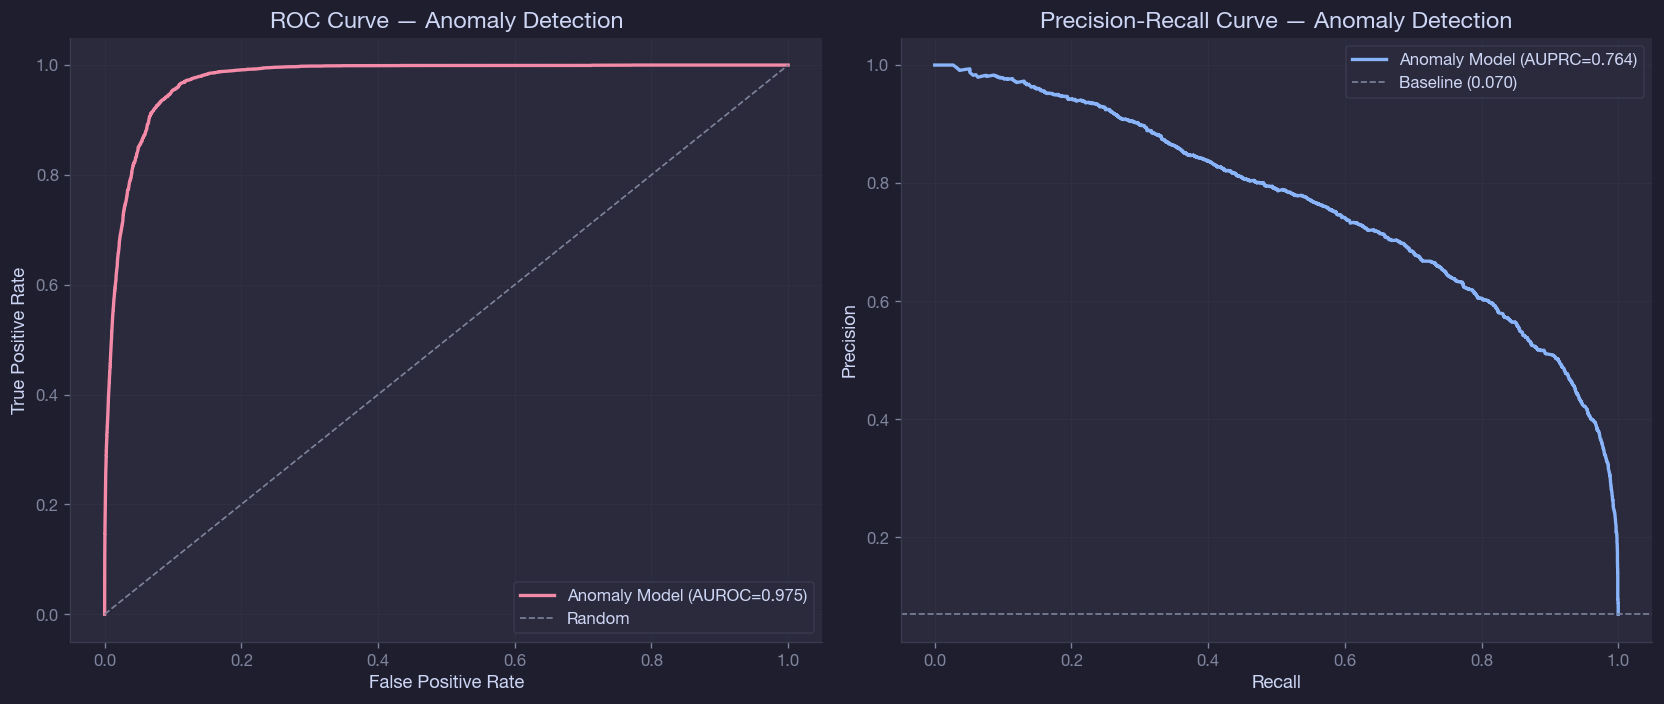

In [5]:
if "anomaly_model" in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC curve
    ax = axes[0]
    fpr, tpr, _ = roc_curve(y_true_anomaly, anomaly_proba)
    ax.plot(fpr, tpr, color=ACCENT[0], linewidth=2, label=f"Anomaly Model (AUROC={auroc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color=PALETTE["text_dim"], linewidth=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve — Anomaly Detection")
    ax.legend(loc="lower right")

    # Precision-Recall curve
    ax = axes[1]
    precision, recall, thresholds = precision_recall_curve(y_true_anomaly, anomaly_proba)
    ax.plot(
        recall, precision, color=ACCENT[1], linewidth=2, label=f"Anomaly Model (AUPRC={auprc:.3f})"
    )
    baseline = y_true_anomaly.mean()
    ax.axhline(
        y=baseline,
        color=PALETTE["text_dim"],
        linestyle="--",
        linewidth=1,
        label=f"Baseline ({baseline:.3f})",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve — Anomaly Detection")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

## 16. Anomaly Model — Feature Importance

Which features are most predictive of anomalous laps?

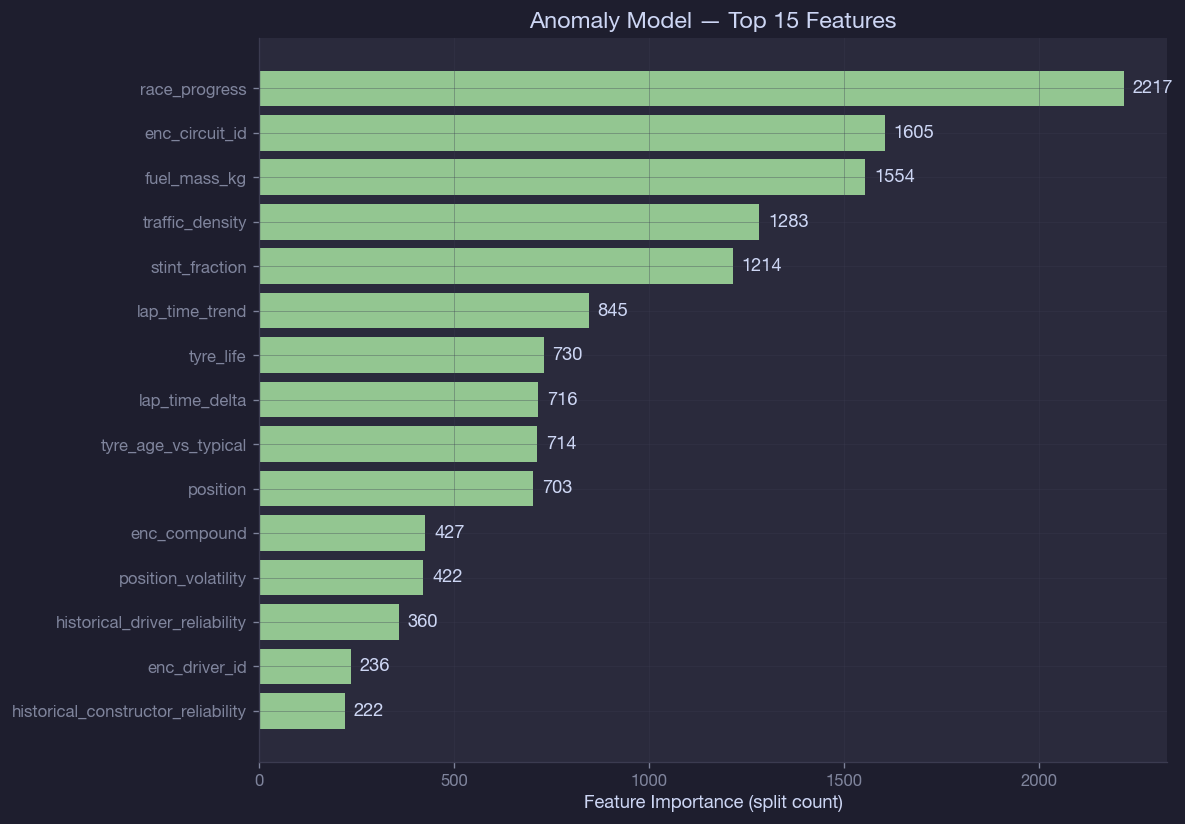

In [6]:
if "anomaly_model" in dir():
    importance_df = anomaly_model.feature_importance()
    top_n = importance_df.head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(range(len(top_n)), top_n["importance"].values, alpha=0.85, color=ACCENT[2])
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels(top_n["feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance (split count)")
    ax.set_title("Anomaly Model — Top 15 Features")

    for bar, val in zip(bars, top_n["importance"].values, strict=False):
        ax.text(
            val + max(top_n["importance"]) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}",
            va="center",
        )

    plt.tight_layout()
    plt.show()

## 17. Anomaly Probability Distribution — Calibration Check

A well-calibrated model should show that laps with predicted probability ~0.3 are actually anomalous ~30% of the time.

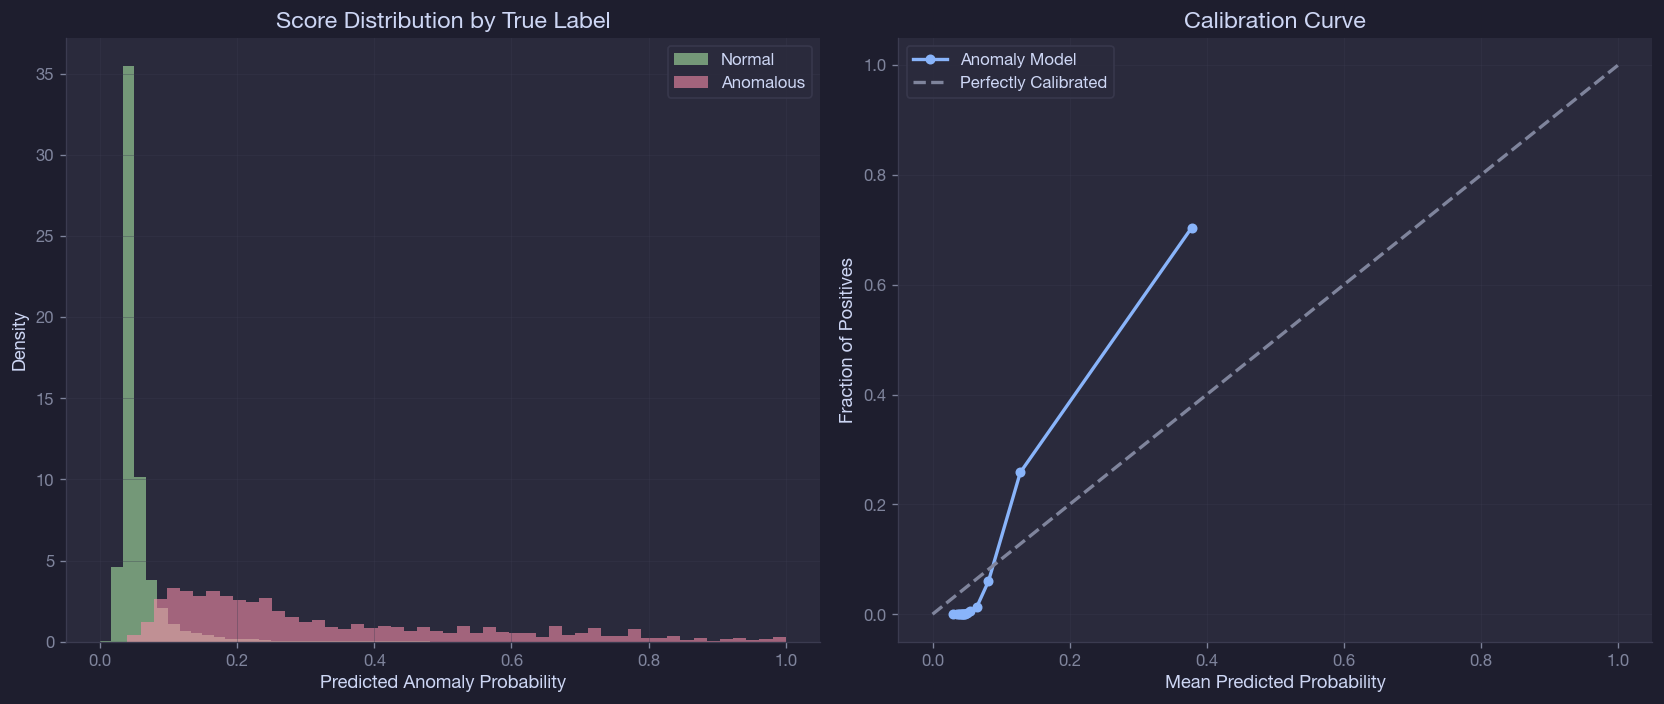

In [7]:
if "anomaly_model" in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Predicted probability distribution
    ax = axes[0]
    ax.hist(
        anomaly_proba[y_true_anomaly == 0],
        bins=50,
        alpha=0.6,
        label="Normal",
        color="#A6E3A1",
        density=True,
    )
    ax.hist(
        anomaly_proba[y_true_anomaly == 1],
        bins=50,
        alpha=0.6,
        label="Anomalous",
        color="#F38BA8",
        density=True,
    )
    ax.set_xlabel("Predicted Anomaly Probability")
    ax.set_ylabel("Density")
    ax.set_title("Score Distribution by True Label")
    ax.legend()

    # 2. Calibration curve
    ax = axes[1]
    from sklearn.calibration import calibration_curve

    prob_true, prob_pred = calibration_curve(
        y_true_anomaly, anomaly_proba, n_bins=15, strategy="quantile"
    )
    ax.plot(prob_pred, prob_true, "o-", color=ACCENT[1], linewidth=2, label="Anomaly Model")
    ax.plot([0, 1], [0, 1], "--", color=PALETTE["text_dim"], label="Perfectly Calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title("Calibration Curve")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 18. Impact of Outlier Removal on Degradation Models

How much does filtering anomalous laps improve degradation model accuracy?
We compare GBM errors on all laps vs. only clean laps.

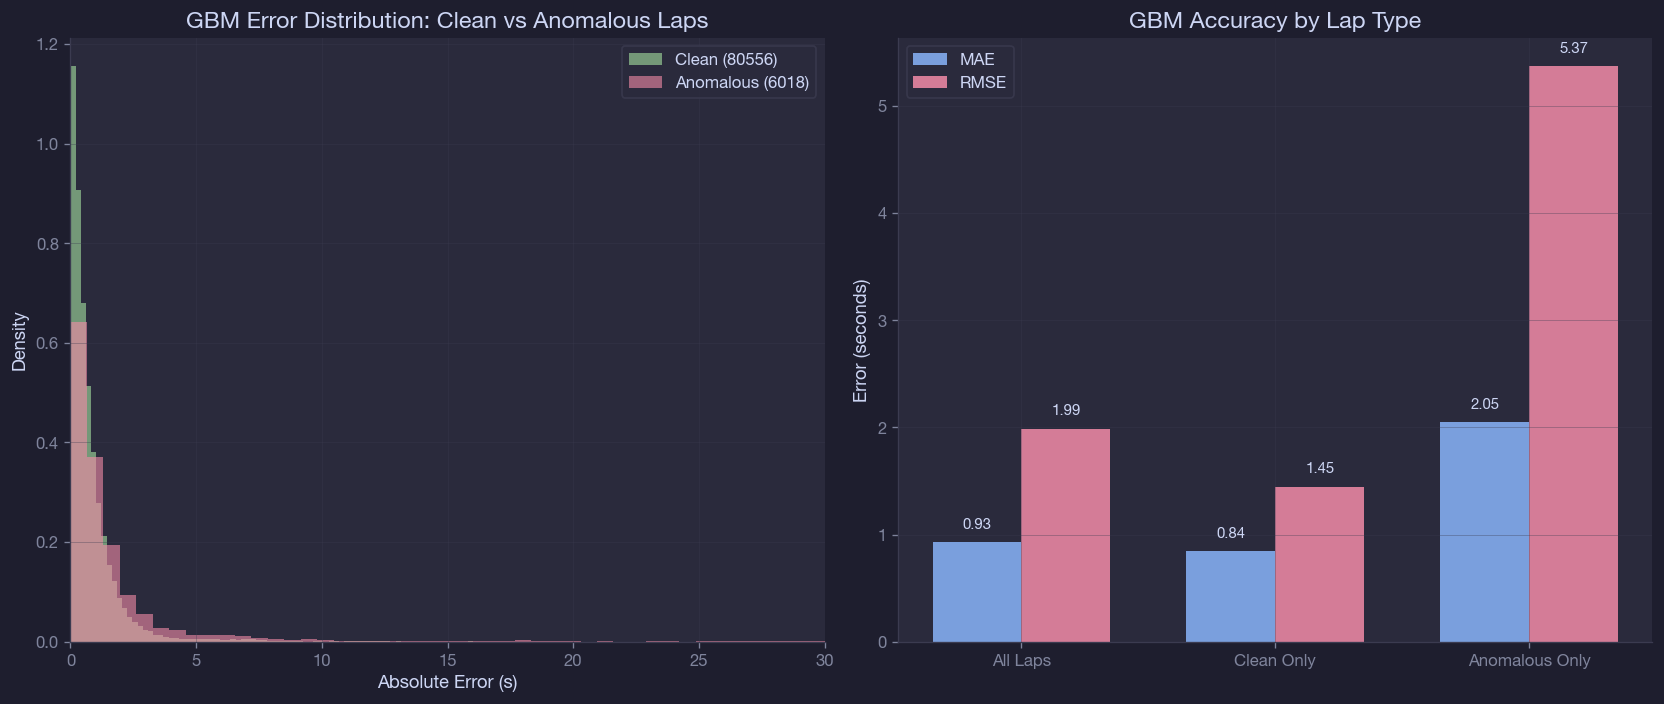


GBM on clean laps: MAE=0.844s, RMSE=1.447s
GBM on anomalous:  MAE=2.048s, RMSE=5.369s
Filtering anomalous laps reduces MAE by 0.084s (9.0%)


In [10]:
if "anomaly_model" in dir() and "gbm" in models:
    gbm_model = models["gbm"]

    # Predict on full dataset
    pred_full = gbm_model.predict(df_full)
    y_full = df_full["lap_time_seconds"].values
    resid_full = y_full - pred_full

    is_anomalous = df_full["is_anomalous_lap"].values.astype(bool)
    is_clean = ~is_anomalous

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Error distribution: anomalous vs clean
    ax = axes[0]
    ax.hist(
        np.abs(resid_full[is_clean]),
        bins=100,
        alpha=0.6,
        label=f"Clean ({is_clean.sum()})",
        color="#A6E3A1",
        density=True,
    )
    ax.hist(
        np.abs(resid_full[is_anomalous]),
        bins=100,
        alpha=0.6,
        label=f"Anomalous ({is_anomalous.sum()})",
        color="#F38BA8",
        density=True,
    )
    ax.set_xlabel("Absolute Error (s)")
    ax.set_ylabel("Density")
    ax.set_title("GBM Error Distribution: Clean vs Anomalous Laps")
    ax.legend()
    ax.set_xlim(0, 30)

    # 2. Summary comparison
    ax = axes[1]
    categories = ["All Laps", "Clean Only", "Anomalous Only"]
    masks = [np.ones(len(resid_full), dtype=bool), is_clean, is_anomalous]
    maes = [np.abs(resid_full[m]).mean() for m in masks]
    rmses = [np.sqrt((resid_full[m] ** 2).mean()) for m in masks]

    x = np.arange(len(categories))
    width = 0.35
    ax.bar(x - width / 2, maes, width, label="MAE", alpha=0.85, color=ACCENT[1])
    ax.bar(x + width / 2, rmses, width, label="RMSE", alpha=0.85, color=ACCENT[0])
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Error (seconds)")
    ax.set_title("GBM Accuracy by Lap Type")
    ax.legend()

    for i, (mae, rmse) in enumerate(zip(maes, rmses, strict=False)):
        ax.text(i - width / 2, mae + 0.1, f"{mae:.2f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + width / 2, rmse + 0.1, f"{rmse:.2f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\nGBM on clean laps: MAE={maes[1]:.3f}s, RMSE={rmses[1]:.3f}s")
    print(f"GBM on anomalous:  MAE={maes[2]:.3f}s, RMSE={rmses[2]:.3f}s")
    print(
        f"Filtering anomalous laps reduces MAE by {maes[0] - maes[1]:.3f}s ({(maes[0] - maes[1]) / maes[0]:.1%})"
    )
elif "gbm" not in models:
    print("GBM model not loaded — skipping impact analysis")